## Shapash: Biblioteca para visualização e compreensão de modelos de ML

#### Instalação e importação de bibliotecas

In [1]:
import pandas as pd

from shapash import SmartExplainer
from shapash.plots.plot_evaluation_metrics import plot_confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

c:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Classificação

In [3]:
dados_churn = pd.read_csv('data\Telco-Customer-Churn.csv',index_col = 'customerID')

In [4]:
dados_churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
x = dados_churn.drop(['TotalCharges', 'Churn'], axis = 1)
y = dados_churn['Churn'].map({'No': 0, 'Yes': 1})

In [6]:
num_cols = list(x.select_dtypes(include=["int64", "float64"]).columns)
cat_cols = list(x.select_dtypes(include=["object"]).columns)

In [7]:
preprocessamento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [8]:
x_transf = preprocessamento.fit_transform(x)
colunas = preprocessamento.get_feature_names_out()

x = pd.DataFrame(
    x_transf.toarray() if hasattr(x_transf, "toarray") else x_transf,
    columns=colunas,
    index=x.index
)

In [9]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify=y, random_state=1)

In [10]:
neg, pos = y_treino.value_counts()
scale_pos_weight = neg / pos

modelo_xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=1)

In [11]:
modelo_xgb.fit(x_treino, y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_previsto = pd.Series(modelo_xgb.predict(x_teste), index = x_teste.index)

In [13]:
plot_confusion_matrix(y_teste,y_previsto)

In [14]:
xpl = SmartExplainer(
    model=modelo_xgb,
    backend='shap', #lime
    preprocessing = preprocessamento,
    label_dict={0: 'No Churn', 1: 'Churn'},
    title_story= 'Relatorio Churn',
    palette_name= 'blues', #default
    )


In [15]:
xpl.compile(
    x=x_teste,
    y_pred= y_previsto,
    y_target=y_teste
)

INFO: Shap explainer type - shap.explainers.PermutationExplainer()


PermutationExplainer explainer: 1410it [01:34, 14.59it/s]                          


In [16]:
summary_df = xpl.to_pandas(max_contrib=3,positive=True,proba=True)
summary_df

,y_pred,proba,feature_1,value_1,contribution_1,feature_2,value_2,contribution_2,feature_3,value_3,contribution_3
7976-CICYS,No Churn,0.967079,num_MonthlyCharges,20.7,0.145076,cat_PaymentMethod,Credit card (automatic),0.052351,cat_InternetService,No,0.038859
0067-DKWBL,Churn,0.794511,num_tenure,2.0,0.178034,cat_Contract,Month-to-month,0.117745,num_MonthlyCharges,49.25,0.077003
2386-OWURY,No Churn,0.724810,num_tenure,58.0,0.236376,cat_gender,Female,0.079978,cat_TechSupport,Yes,0.046587
4439-YRNVD,No Churn,0.853620,cat_InternetService,DSL,0.093012,cat_OnlineBackup,Yes,0.081696,num_MonthlyCharges,36.25,0.070286
9574-BOSMD,No Churn,0.999619,cat_Contract,Two year,0.121232,num_tenure,68.0,0.068451,num_MonthlyCharges,25.4,0.039098
...,...,...,...,...,...,...,...,...,...,...,...
4900-MSOMT,No Churn,0.999575,cat_Contract,Two year,0.146491,num_tenure,72.0,0.112575,cat_InternetService,DSL,0.030422
8161-QYMTT,Churn,0.958660,cat_Contract,Month-to-month,0.178866,num_tenure,7.0,0.16399,cat_InternetService,Fiber optic,0.081404
4201-JMNGR,Churn,0.709453,num_tenure,1.0,0.225267,cat_Contract,Month-to-month,0.141356,cat_PaperlessBilling,Yes,0.043817
0739-UUAJR,No Churn,0.997448,num_tenure,72.0,0.15781,cat_Contract,Two year,0.127473,cat_InternetService,DSL,0.030598


In [17]:
xpl.plot.features_importance()

In [18]:
xpl.plot.local_plot(index='0067-DKWBL')

In [19]:
xpl.plot.local_plot(index='7976-CICYS')

In [44]:
xpl.save('xpl.pkl')

In [2]:
xpl = SmartExplainer.load("xpl.pkl")

In [ ]:
app = xpl.run_app()

INFO:root:Your Shapash application run on http://joaom:8050/
INFO:root:Use the method .kill() to down your app.


Exception in thread Thread-3 (<lambda>):
Traceback (most recent call last):
  File "c:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
  File "c:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
OSError: [WinError 10049] O endereço solicitado não é válido no contexto

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen
    response = self._make_request(
  File "c:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\lib\site-packages\urllib3\connectionpo

In [9]:
app.kill()

### Geração de relatórios HTML

In [1]:
# %pip install shapash shapash[report]

Tive que alterar a função da biblioteca para utilizar o encoding UTF-8. Estava apresentando erro de codec.

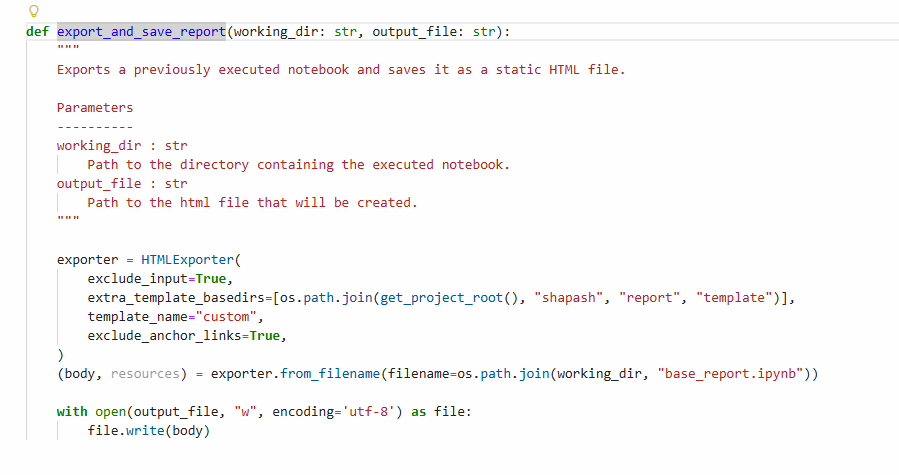

In [43]:
xpl.generate_report(
        output_file='report.html',
        project_info_file='utils/project_info.yml',
        x_train=x_treino,
        y_train=y_treino,
        y_test=y_teste,
        title_story="Relatório de Churn",
        title_description="Esse documento é um relatorio do modelo de classificação de Churn",
        metrics=[
           {
        "path": "sklearn.metrics.accuracy_score",
        "name": "Acuracia"
    },
    {
        "path": "sklearn.metrics.precision_score",
        "name": "Precision"
    },
    {
        "path": "sklearn.metrics.recall_score",
        "name": "Recall"
    },
    {
        "path": "sklearn.metrics.f1_score",
        "name": "F1-Score"
    }
            ]
    )

INFO:papermill:Input Notebook:  C:\Users\JoãoMiranda\Documents\projetos\shapash\.venv\Lib\site-packages\shapash\report\base_report.ipynb
INFO:papermill:Output Notebook: C:\Users\JOOMIR~1\AppData\Local\Temp\tmpqwfoh3fa\base_report.ipynb
Executing: 100%|██████████| 15/15 [00:12<00:00,  1.18cell/s]
